# EDA & Feature Engineering

Loads AAPL price data, builds SMA/EMA, lagged returns, volatility, and momentum features, then saves the processed dataset to `../data/features.csv` for use in the modelling notebook.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor

In [2]:
#
data = yf.Ticker("AAPL") #creates ticker object for apple stocks everything will be referencing this object
data.info # returns a large dict of general comp info: market cap, sector, P/E ratio, 52-week high/low
data.calendar #returns upcoming events like earnings dates and expected EPS ranges
data.analyst_price_targets #retunrs analyst consensus price targets(low, mean, high, current)
data.quarterly_income_stmt #returns the last few quarters of income statement data: rev, gross profit, net income
data.history(period='1mo') # returns a df of daily OHLCV price data for the past 1 month
data.option_chain(data.options[0]).calls # gets the nearest exp dat from the list of options  and fetches 
# the options chain for the date and reutnrs just the call contracts 


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260515C00005000,2026-05-12 15:18:39+00:00,5.0,293.99,292.00,295.90,4.940002,1.709048,1.0,0,21.625003,True,REGULAR,USD
1,AAPL260515C00010000,2026-05-12 15:27:30+00:00,10.0,283.83,287.25,290.50,0.000000,0.000000,6.0,0,13.500002,True,REGULAR,USD
2,AAPL260515C00015000,2026-05-12 15:28:01+00:00,15.0,278.85,282.20,285.90,0.000000,0.000000,8.0,2,16.687505,True,REGULAR,USD
3,AAPL260515C00020000,2026-05-12 15:28:01+00:00,20.0,276.15,277.00,281.10,2.279999,0.832511,1.0,1,14.953126,True,REGULAR,USD
4,AAPL260515C00025000,2026-04-23 19:39:41+00:00,25.0,271.25,272.25,275.90,22.619995,9.097854,1.0,0,13.859376,True,REGULAR,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,AAPL260515C00410000,2026-04-27 18:14:29+00:00,410.0,0.02,0.00,0.01,0.000000,0.000000,2.0,408,1.312503,False,REGULAR,USD
87,AAPL260515C00420000,2026-05-12 19:45:15+00:00,420.0,0.01,0.00,0.01,0.000000,0.000000,2.0,141,1.406253,False,REGULAR,USD
88,AAPL260515C00430000,2026-04-20 13:30:04+00:00,430.0,0.01,0.00,0.01,0.000000,0.000000,2.0,143,1.500002,False,REGULAR,USD
89,AAPL260515C00440000,2026-05-13 13:30:02+00:00,440.0,0.01,0.00,0.01,0.000000,0.000000,1.0,89,1.562502,False,REGULAR,USD


## Simple Moving Average (SMA)

The SMA averages the closing price over the past $n$ days with equal weight:

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

where $P_t$ is the closing price at time $t$ and $n$ is the window size. The first $n-1$ values are undefined ($\text{NaN}$) since there are not enough prior observations to fill the window.

---

## Exponential Moving Average (EMA)

The EMA applies exponentially decaying weights so that recent prices matter more:

$$\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$$

where the smoothing factor $\alpha$ is:

$$\alpha = \frac{2}{n + 1}$$

As prices get older, the weight $(1-\alpha)^i$ shrinks toward zero — recent prices dominate. Unlike SMA, EMA produces no $\text{NaN}$ gap at the start since it is computed recursively from the first observation.

---

## Why Calculate SMA and EMA?

**Trend Identification**
- Price above SMA/EMA → uptrend; price below → downtrend
- Smooths out day-to-day noise so the broader direction is clearer

**Signal Generation (Crossovers)**
- When a short-term MA crosses above a long-term MA → *golden cross* (bullish signal)
- When it crosses below → *death cross* (bearish signal)

**ML Feature Engineering**
- Raw price is non-stationary (trends upward over time), which hurts model performance
- SMA and EMA give the model a sense of where price has been trending, capturing momentum without overfitting to raw price levels

**EMA vs SMA**
- EMA reacts faster to recent price changes, making it more useful for short-term prediction
- SMA is smoother and better for identifying long-term trends

In [3]:
#simple moving average (30-days)
history = data.history(period='5y')
history['SMA30'] = history['Close'].rolling(window=30).mean() 
sma_30 = history['Close'].rolling(window=30).mean() 

#exponential moving average (50 days)
history['EMA50'] = history['Close'].ewm(span=50, adjust=False).mean()

print(history[['Close','SMA30','EMA50']])

                                Close       SMA30       EMA50
Date                                                         
2021-05-14 00:00:00-04:00  124.232132         NaN  124.232132
2021-05-17 00:00:00-04:00  123.081917         NaN  124.187025
2021-05-18 00:00:00-04:00  121.697777         NaN  124.089408
2021-05-19 00:00:00-04:00  121.541809         NaN  123.989502
2021-05-20 00:00:00-04:00  124.095657         NaN  123.993665
...                               ...         ...         ...
2026-05-07 00:00:00-04:00  287.175415  265.648583  266.366010
2026-05-08 00:00:00-04:00  293.050018  266.995010  267.412442
2026-05-11 00:00:00-04:00  292.679993  268.465310  268.403326
2026-05-12 00:00:00-04:00  294.799988  270.078544  269.438489
2026-05-13 00:00:00-04:00  298.869995  271.588997  270.592666

[1255 rows x 3 columns]


## Lagged Returns

---

A **lagged return** is a time-shifted copy of the returns column. Each lag represents what the return was $n$ days ago:

- **Lag1** — yesterday's return $(t-1)$
- **Lag2** — two days ago $(t-2)$
- **Lag3** — three days ago $(t-3)$

Lags turn a time series prediction problem into a standard regression problem — instead of predicting across time, the model predicts today's return $y$ from a set of past return features $X$.

---

## Models Being Implemented

**Linear Regression (completed)**
Uses the Normal Equation to find the optimal weights for the lagged return features. Serves as the baseline model.

**Random Forest (up next)**
A tree-based model that captures non-linear relationships between features and returns that linear regression cannot.

**XGBoost (up next)**
A gradient boosted tree model that handles complex feature interactions and typically outperforms random forest on tabular data.

---

## Features Being Added

| Feature | Description | Method |
|---------|-------------|--------|
| Lag1, Lag2, Lag3 | Past returns | `.shift(n)` |
| Volatility | Recent price swings | `.rolling(5).std()` |
| Momentum | Short term trend | `.rolling(5).mean()` |
| SMA Ratio | Price vs moving average | `Close / SMA30` |

In [4]:
history['Return'] = history['Close'].pct_change()

#each lag shifts the return column down by n days
history['Lag1'] = history['Return'].shift(1) #returns on day t-1
history['Lag2'] = history['Return'].shift(2) #returns on day t-2
history['Lag3'] = history['Return'].shift(3) #returns on day t-3
history['Lag7'] = history['Return'].shift(7) #returns on day t-7
history['Lag30'] = history['Return'].shift(30) #returns on day t-30

#volatility - rolling standard deviation of returns
history['Vol_5day'] = history['Return'].rolling(window=5).std()
history['Vol_30day'] = history['Return'].rolling(window=30).std()
history['Vol_90day'] = history['Return'].rolling(window=90).std()
history['Vol_252day'] = history['Return'].rolling(window=252).std()

#momentum - rolling mean of returns
history['Momentum_5days'] = history['Return'].rolling(window=5).mean()
history['Momentum_30days'] = history['Return'].rolling(window=30).mean()
history['Momentum_90days'] = history['Return'].rolling(window=90).mean()
history['Momentum_252days'] = history['Return'].rolling(window=252).mean()


history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3', 'Vol_5day', 'Momentum_5days']]

,Close,Return,Lag1,Lag2,Lag3,Vol_5day,Momentum_5days
Date,,,,,,,
2021-05-14 00:00:00-04:00,124.232132,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-17 00:00:00-04:00,123.081917,-0.009259,NaN,NaN,NaN,NaN,NaN
2021-05-18 00:00:00-04:00,121.697777,-0.011246,-0.009259,NaN,NaN,NaN,NaN
2021-05-19 00:00:00-04:00,121.541809,-0.001282,-0.011246,-0.009259,NaN,NaN,NaN
2021-05-20 00:00:00-04:00,124.095657,0.021012,-0.001282,-0.011246,-0.009259,NaN,NaN
...,...,...,...,...,...,...,...
2026-05-07 00:00:00-04:00,287.175415,-0.000244,0.011718,0.026551,-0.011816,0.018333,0.011721
2026-05-08 00:00:00-04:00,293.050018,0.020456,-0.000244,0.011718,0.026551,0.015531,0.009333
2026-05-11 00:00:00-04:00,292.679993,-0.001263,0.020456,-0.000244,0.011718,0.012324,0.011444


In [5]:
#dropped all rows with NaN
history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']].dropna()

,Close,Return,Lag1,Lag2,Lag3
Date,,,,,
2021-05-20 00:00:00-04:00,124.095657,0.021012,-0.001282,-0.011246,-0.009259
2021-05-21 00:00:00-04:00,122.263138,-0.014767,0.021012,-0.001282,-0.011246
2021-05-24 00:00:00-04:00,123.890961,0.013314,-0.014767,0.021012,-0.001282
2021-05-25 00:00:00-04:00,123.696022,-0.001573,0.013314,-0.014767,0.021012
2021-05-26 00:00:00-04:00,123.647270,-0.000394,-0.001573,0.013314,-0.014767
...,...,...,...,...,...
2026-05-07 00:00:00-04:00,287.175415,-0.000244,0.011718,0.026551,-0.011816
2026-05-08 00:00:00-04:00,293.050018,0.020456,-0.000244,0.011718,0.026551
2026-05-11 00:00:00-04:00,292.679993,-0.001263,0.020456,-0.000244,0.011718


## Volatility

**Volatility** measures how much returns have been swinging over a recent window of days. It does not measure direction — only the size of the moves.

It is calculated as the **rolling standard deviation** of returns:

$$\text{Vol}_t = \sqrt{\frac{1}{n-1} \sum_{i=0}^{n-1} (R_{t-i} - \bar{R})^2}$$

A higher value means the stock has been making large moves recently (high risk), a lower value means it has been calm.

**Why it helps the model:**
- Volatile periods tend to cluster — big moves are often followed by more big moves
- Giving the model recent volatility helps it adjust its predictions based on the current market regime

**Windows used:** 5-day (short term, reactive) and 30-day (long term, stable). The 5-day line is jagged and reacts quickly to sudden events, while the 30-day line is smoother and reflects the broader volatility environment.

In [6]:
#printing out as grids for sanity check
history[['Vol_5day','Vol_30day','Vol_90day','Vol_252day']]

,Vol_5day,Vol_30day,Vol_90day,Vol_252day
Date,,,,
2021-05-14 00:00:00-04:00,NaN,NaN,NaN,NaN
2021-05-17 00:00:00-04:00,NaN,NaN,NaN,NaN
2021-05-18 00:00:00-04:00,NaN,NaN,NaN,NaN
2021-05-19 00:00:00-04:00,NaN,NaN,NaN,NaN
2021-05-20 00:00:00-04:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-05-07 00:00:00-04:00,0.018333,0.015811,0.015564,0.014643
2026-05-08 00:00:00-04:00,0.015531,0.016063,0.015703,0.014668
2026-05-11 00:00:00-04:00,0.012324,0.015607,0.015700,0.014666


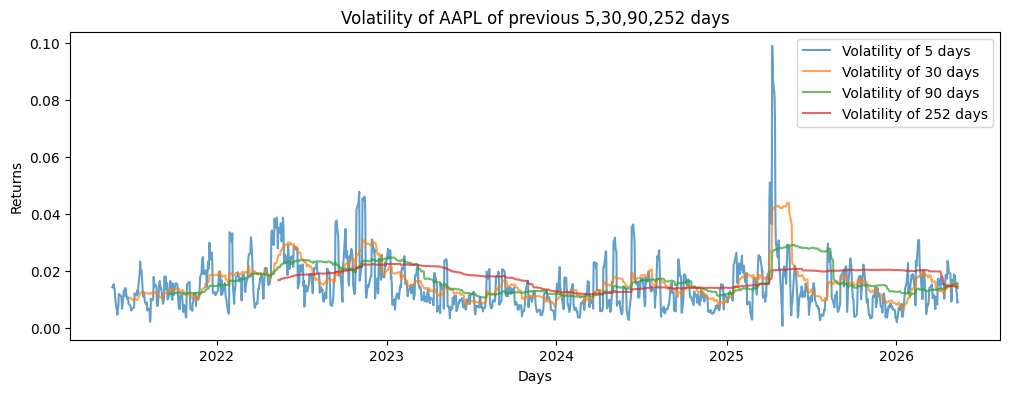

In [7]:
plt.figure(figsize=(12,4))
plt.plot(history['Vol_5day'],label='Volatility of 5 days',alpha=0.7)
plt.plot(history['Vol_30day'],label='Volatility of 30 days',alpha=0.7)
plt.plot(history['Vol_90day'],label='Volatility of 90 days',alpha=0.7)
plt.plot(history['Vol_252day'],label='Volatility of 252 days',alpha=0.7)
plt.title('Volatility of AAPL of previous 5,30,90,252 days')
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.show()

## Momentum

**Momentum** measures the **direction** of recent returns — whether the stock has been trending up or down over a window of days. Unlike volatility it does care about direction, not just magnitude.

It is calculated as the **rolling mean** of returns:

$$\text{Momentum}_t = \frac{1}{n} \sum_{i=0}^{n-1} R_{t-i}$$

- **Positive momentum** → stock has been going up on average recently
- **Negative momentum** → stock has been trending down
- **Near zero** → no clear direction

**Why it helps the model:**
- Stocks that have been rising tend to keep rising in the short term (momentum effect)
- Gives the model a sense of the current trend direction, complementing the volatility feature which only captures the size of moves

**Windows used:** 5-day, 10-day, 15-day, and 30-day. Shorter windows react faster to recent changes, longer windows reflect the broader trend.

In [8]:
history[['Momentum_5days','Momentum_30days']]

,Momentum_5days,Momentum_30days
Date,,
2021-05-14 00:00:00-04:00,NaN,NaN
2021-05-17 00:00:00-04:00,NaN,NaN
2021-05-18 00:00:00-04:00,NaN,NaN
2021-05-19 00:00:00-04:00,NaN,NaN
2021-05-20 00:00:00-04:00,NaN,NaN
...,...,...
2026-05-07 00:00:00-04:00,0.011721,0.004434
2026-05-08 00:00:00-04:00,0.009333,0.005080
2026-05-11 00:00:00-04:00,0.011444,0.005577


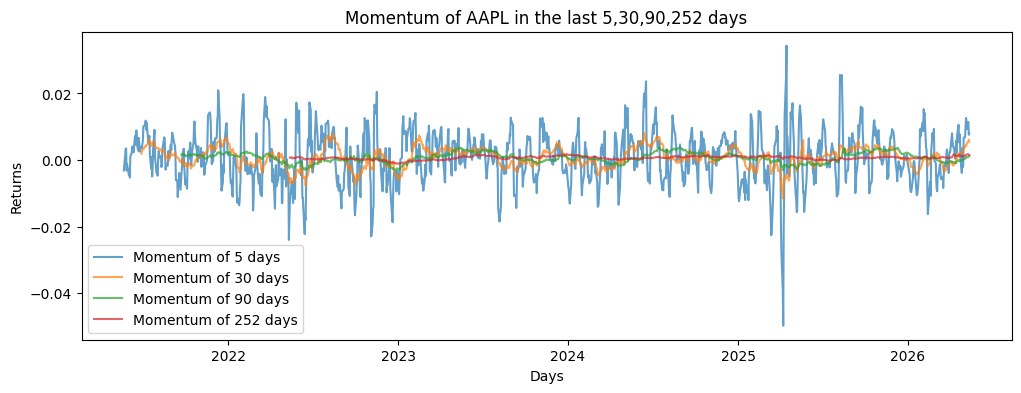

In [9]:
plt.figure(figsize=(12,4))
plt.plot(history['Momentum_5days'],label = 'Momentum of 5 days',alpha = 0.7)
plt.plot(history['Momentum_30days'],label = 'Momentum of 30 days',alpha = 0.7)
plt.plot(history['Momentum_90days'],label = 'Momentum of 90 days',alpha = 0.7)
plt.plot(history['Momentum_252days'],label = 'Momentum of 252 days',alpha = 0.7)
plt.title('Momentum of AAPL in the last 5,30,90,252 days')
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.show()

## SMA Ratio

**SMA Ratio** measures where the current price sits relative to its 30-day moving average:

$$\text{SMA Ratio}_t = \frac{\text{Close}_t}{\text{SMA30}_t}$$

- **SMA Ratio > 1** → price is above its 30-day average → stock is in an uptrend
- **SMA Ratio < 1** → price is below its 30-day average → stock is in a downtrend
- **SMA Ratio = 1** → price is exactly at its average

**Why it is useful:**
- Raw price is non-stationary and hard for a model to interpret across time
- The ratio normalizes price into a relative measure — telling the model not that the price is $294 but that it is 8.8% above its recent trend
- This makes it a consistent signal regardless of the price level or time period

**Note:** After inspecting the feature weights from the linear regression model, SMA Ratio had a weight of -0.01 — near zero — meaning it contributed almost no predictive power. It was dropped from the final feature set to reduce overfitting.

In [10]:
#SMA ratio - closing price relative to 30-day moving average
history['SMA_Ratio'] = history['Close'] / sma_30

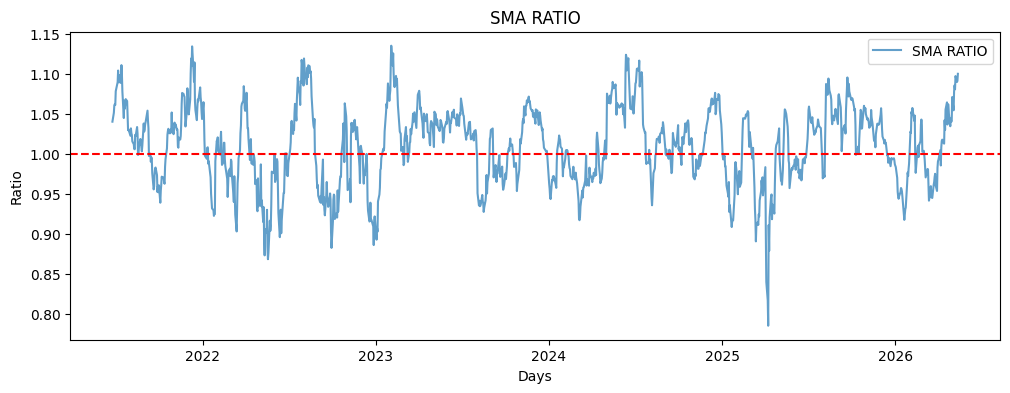

In [11]:
plt.figure(figsize=(12,4))
plt.plot(history['SMA_Ratio'], label = 'SMA RATIO', alpha = 0.7)
plt.xlabel('Days')
plt.ylabel('Ratio')
plt.title('SMA RATIO')
plt.axhline(y=1,color='red',linestyle = '--')
plt.legend()
plt.show()

In [12]:
#drop NaN rows and save back to history, then split into X (features) and y (target)
feature_cols = ['Lag1', 'Lag2', 'Lag3','Lag7','Lag30',
                'Vol_5day', 'Vol_30day','Vol_90day','Vol_252day',
                'Momentum_5days', 'Momentum_30days','Momentum_90days', 'Momentum_252days']

history = history[['Close', 'Return'] + feature_cols].dropna()

X = history[feature_cols].values
y = history['Return'].values

## Reading the Visualizations

---

### 1. Returns Over Time

The y-axis is the daily return as a decimal — `0.02` = 2% gain, `-0.03` = 3% loss. You are looking for:
- How volatile the stock is (how tall the spikes are)
- Any clustering of big moves (volatility tends to cluster together)
- General pattern of ups and downs over the year

---

### 2. Lag Correlation Scatter Plots

Each dot is one trading day. The x-axis is the lagged return (e.g. yesterday's return) and the y-axis is today's return — both in decimal form.

You are looking for a pattern in the dots:
- **Diagonal trend (up-right / down-left)** → past returns predict future returns (momentum)
- **No pattern, random cloud** → past returns have no predictive power
- The more scattered the dots, the weaker the relationship

---

### 3. Correlation Heatmap

The numbers range from $-1$ to $1$:
- $1.0$ → perfect positive correlation (move together)
- $-1.0$ → perfect negative correlation (move opposite)
- $0.0$ → no relationship at all

For stock returns you would typically see values very close to $0$ between lags and today's return. This is consistent with the **Efficient Market Hypothesis (EMH)**, which states that prices already reflect all available information — so past returns should not strongly predict future ones.

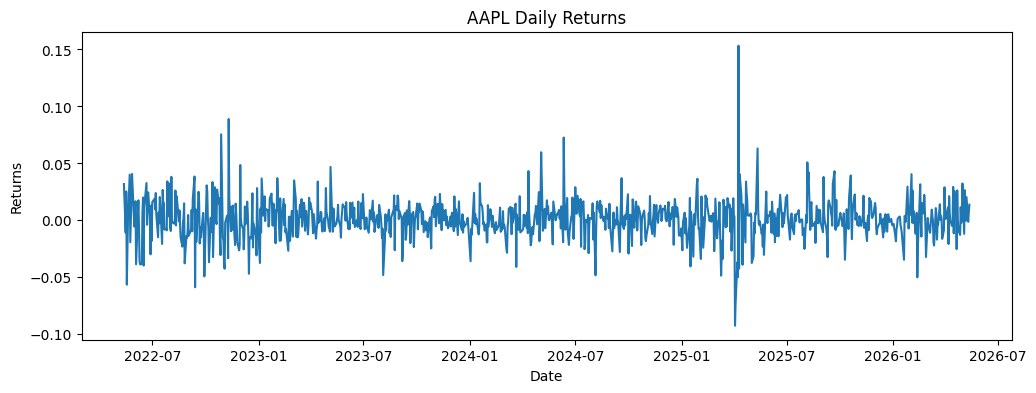

In [13]:
#Returns over time
plt.figure(figsize=(12,4))
plt.plot(history.index, history['Return'])
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

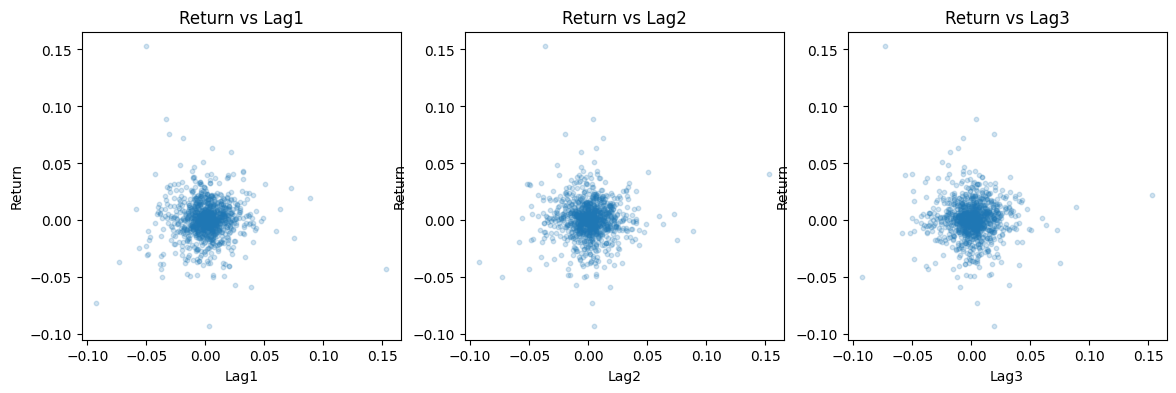

In [17]:
#Lag correlation scatter plot
fig, axes = plt.subplots(1,3,figsize=(14,4))

for i, lag in enumerate(['Lag1', 'Lag2', 'Lag3']):
    axes[i].scatter(history[lag], history['Return'], alpha=0.2, s=10)
    axes[i].set_xlabel(lag)
    axes[i].set_ylabel('Return')
    axes[i].set_title(f'Return vs {lag}')

plt.tight_layout
plt.show()

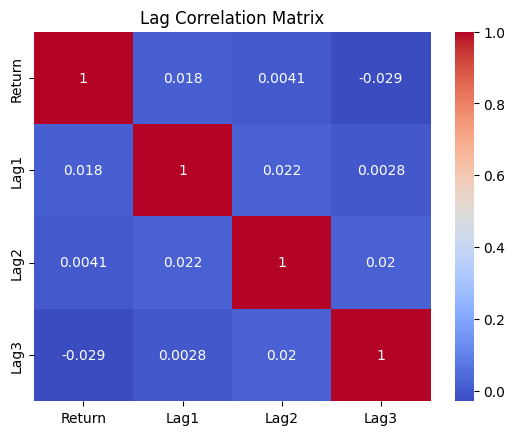

In [15]:
#correlation heatmap
corr = history[['Return','Lag1','Lag2','Lag3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Lag Correlation Matrix')
plt.show()

In [16]:
import os
os.makedirs('../data', exist_ok=True)
history.to_csv('../data/features.csv')
print('Saved ../data/features.csv')

Saved ../data/features.csv
